# Tải dữ liệu

In [37]:
# !kaggle datasets download -d furcifer/fane-facial-expressions-and-emotion-dataset -p ./Dts/ --unzip

# Load Data

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split


train = pd.read_csv("spaceship-titanic/train.csv")
test = pd.read_csv("spaceship-titanic/test.csv")
print(train.shape)
print(test.shape)
train.head()

(8693, 14)
(4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Khám phá dữ liệu

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object
PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64


<Axes: xlabel='Transported', ylabel='count'>

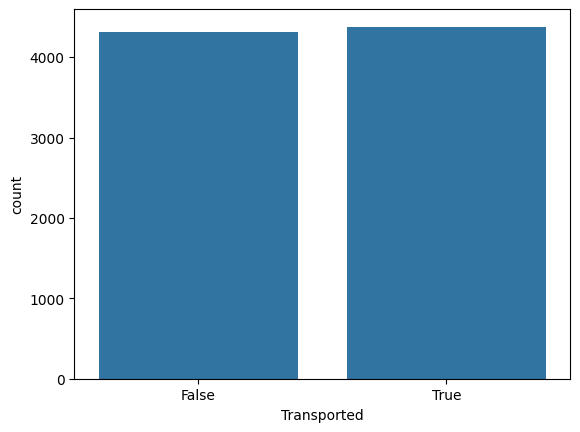

In [39]:
print(train.dtypes)
train["Destination"].value_counts()
print(train.isnull().mean() * 100)
sb.countplot(x="Transported", data=train)


Dữ liệu bị null khá ít => Miền median với biến số, điền mode với biến phân loại

Dữ đầu vào khá cân bằng (gần như là tỉ lệ 50:50)

Xoá cột tên đi :)) chắc là ko có ai thiên vị về tên đâu

# Drop cột Name

In [40]:
train = train.drop(columns=["Name"])
test = test.drop(columns=["Name"])


In [41]:
train["Cabin"].value_counts()
print(train.dtypes)

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Transported        bool
dtype: object


Cabin quá nhiều loại, mỗi loại bao gồm 3 thành phần (deck/num/side) => tách làm 3 cột dữ liệu

CryoSleep và VIP có giá trị là True/False mà có dạng là object nên đổi thành bool

# Tách dữ liệu

In [42]:
# Tách Cabin

train[["Deck", "Num", "Side"]] = train["Cabin"].str.split("/", expand=True)
test[["Deck", "Num", "Side"]] = test["Cabin"].str.split("/", expand=True)

# Chuyển CabinNum sang số
train["Num"] = pd.to_numeric(train["Num"], errors="coerce")
test["Num"] = pd.to_numeric(test["Num"], errors="coerce")


# Drop cột
X = train.drop(columns=["Transported","PassengerId"])
X_test_kaggle = test.drop(columns=["PassengerId"])

# Xoá cột trong
X = X.drop(columns=["Cabin"])
X_test_kaggle = X_test_kaggle.drop(columns=["Cabin"])
y = train["Transported"].astype(int)

result = {}

# Fill null

In [43]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cate_cols = X.select_dtypes(include=["object", "bool"]).columns

for col in num_cols:
    med = X[col].median()
    X[col] = X[col].fillna(med)
    if col in X_test_kaggle.columns:
        X_test_kaggle[col] = X_test_kaggle[col].fillna(med)

for col in cate_cols:
    mode_val = train[col].mode()[0]
    X[col] = X[col].fillna(mode_val)
    if col in X_test_kaggle.columns:
        X_test_kaggle[col] = X_test_kaggle[col].fillna(mode_val)

C:\Users\Crink\AppData\Local\Temp\ipykernel_34632\4276190299.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cate_cols = X.select_dtypes(include=["object", "bool"]).columns


# Get_dummies cho categorical columns

In [44]:
split_col = ["Destination","HomePlanet","Deck", "Side"]
# Tách cột
X = pd.get_dummies(X, columns=split_col, drop_first=False)
X_test_kaggle = pd.get_dummies(X_test_kaggle, columns=split_col, drop_first=False)

# Split test

In [45]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify= y,
    random_state=36
)

# Convert CryoSleep, VIP → bool

In [46]:
for col in ["CryoSleep", "VIP"]:
    X_test_kaggle[col] = X_test_kaggle[col].astype(bool)
    X_test[col] = X_test[col].astype(bool)
    X_train[col] = X_train[col].astype(bool)      # ← THÊM DÒNG NÀY     

# Bagging

In [72]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=36,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred_kaggle = rf.predict(X_test_kaggle)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

# Boosting

In [ ]:

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred_kaggle = xgb.predict(X_test_kaggle)

xgb_pred = xgb.predict(X_test)
xgb_pred_kaggle = xgb.predict(X_test_kaggle)

xgb_acc = accuracy_score(y_test,xgb_pred)

# Stacking

In [ ]:
estimators = [
    ("rf", rf),
    ("xgb", xgb)
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train, y_train)

stack_pred_kaggle = stack.predict(X_test_kaggle)

stack_pred = stack.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)


CryoSleep                    0
Age                          0
VIP                          0
RoomService                  0
FoodCourt                    0
ShoppingMall                 0
Spa                          0
VRDeck                       0
Num                          0
Destination_55 Cancri e      0
Destination_PSO J318.5-22    0
Destination_TRAPPIST-1e      0
HomePlanet_Earth             0
HomePlanet_Europa            0
HomePlanet_Mars              0
Deck_A                       0
Deck_B                       0
Deck_C                       0
Deck_D                       0
Deck_E                       0
Deck_F                       0
Deck_G                       0
Deck_T                       0
Side_P                       0
Side_S                       0
dtype: int64
Stacking (đa dạng model) accuracy: 0.8039102932719954


# Báo cáo benchmark

In [69]:
models = {
    "Bagging": rf_acc,
    "Boosting": xgb_acc,
    "Stacking": stack_acc
}

results = {}

for name, acc in models.items():
    results[name] = acc

pd.DataFrame(results.items(), columns=["Method", "Accuracy"])

,Method,Accuracy
0,Bagging,0.810236
1,Boosting,0.803910
2,Stacking,0.803910


# Xuất dữ liệu predict qua file csv để nộp

In [70]:
xgb_pred_kaggle =  xgb_pred_kaggle.astype(bool)
sub =  pd.DataFrame(
    {
        "PassengerId": test["PassengerId"].astype(str),
        "Transported": xgb_pred_kaggle
    }
)
sub.to_csv("submission.csv", index=False)